# Introduction to the VEClim API

This tutorial provides a step-by-step introduction to accessing and visualising outputs from the VEClim API, with a focus on recent predictions of *Aedes albopictus* population activity and associated disease risk.

You will learn how to query the API for time series data at specific locations, interpret the returned outputs, and generate basic visualisations to support exploratory analysis and decision-making. The examples are designed to be easily adapted for different regions and time periods.

Further details on the structure, functionality, and underlying modelling framework of the VEClim API are provided in [Erguler et al. 2019, *Wellcome Open Research*](https://doi.org/10.12688/wellcomeopenres.23122.1).

Let's begin by loading the libraries we will need:

In [ ]:
library(httr2)
library(jsonlite)
library(dplyr)
library(ggplot2)

Access to the VEClim REST API is provided through a simple GET request. In the example below, we request daily time series outputs for *Aedes albopictus* at a given location and date range:

In [ ]:
lon <- 10.75
lat <- 44.75
date0 <- "2026-01-01"
date1 <- "2026-12-31"

url <- paste0(
  "https://veclim.com/api?",
  "vec=albopictus",
  "&lon=", lon,
  "&lat=", lat,
  "&dates=", date0, ":", date1,
  "&opr=ts"
)

We then retrieve the response and parse it as JSON. Note that VEClim responses may contain `NaN` values, which are not strictly valid in standard JSON format. We therefore replace them with `null` prior to parsing:

In [ ]:
txt <- request(url) |> req_perform() |> resp_body_string()

# Replace invalid JSON NaN tokens with null
txt <- gsub("\\bNaN\\b", "null", txt)

js <- jsonlite::fromJSON(txt)

The returned object contains several time series components. The decadal reference time series is stored in `js$sim-ts$2010-2019$colegg` and spans the full date range from `js$date$date0` to `js$date$date1`, with one value per day.

The seasonal forecast time series is stored in `js$fcast-ts$ecmwf$colegg`. This series also begins at `js$date$date0`, but may terminate earlier depending on forecast availability.

The field `js$fcast-ts$ecmwf$overlap` contains two dates that delimit the transition between ERA5-driven and ECMWF-driven components of the forecast. This allows the forecast to be separated into three segments: ERA5-only, overlap, and ECMWF-only.

The following script extracts these components and organises them into data frames suitable for plotting:

In [ ]:
date0 <- as.Date(js$date$date0)
date1 <- as.Date(js$date$date1)

# Decadal
y_dec <- js$`sim-ts`$`2010-2019`$colegg
x_dec <- seq.Date(date0, date1, by = "day")

df_dec <- data.frame(date = x_dec, value = y_dec)
df_dec$series <- "Decadal"

# Forecast
y_f <- js$`fcast-ts`$ecmwf$colegg
x_f <- seq.Date(date0, by = "day", length.out = length(y_f))

overlap <- as.Date(js$`fcast-ts`$ecmwf$overlap)
era5_end <- overlap[1]
ecmwf_start <- overlap[2]

df_f <- data.frame(date = x_f, value = y_f)
df_f$series <- "Overlap"
df_f$series[df_f$date < ecmwf_start] <- "ERA5 only"
df_f$series[df_f$date > era5_end] <- "ECMWF only"

Observational data from the VectAbundance dataset can also be included if available. This is provided in `js$surv-ts$vabun` and aligned with the same daily time axis:

In [ ]:
# ---- Optional: Surveillance (vabun) ---------------------------------------------------
y_surv <- js$`surv-ts`$vabun
y_surv[is.nan(y_surv)] <- NA_real_
x_surv <- seq.Date(date0, date1, by = "day")
df_surv <- data.frame(
  date = x_surv,
  value = y_surv,
  series = "VectAbundance")

Finally, we visualise the results. Since the observational data may be on a different scale, we rescale it for display and provide a secondary axis to retain interpretability:

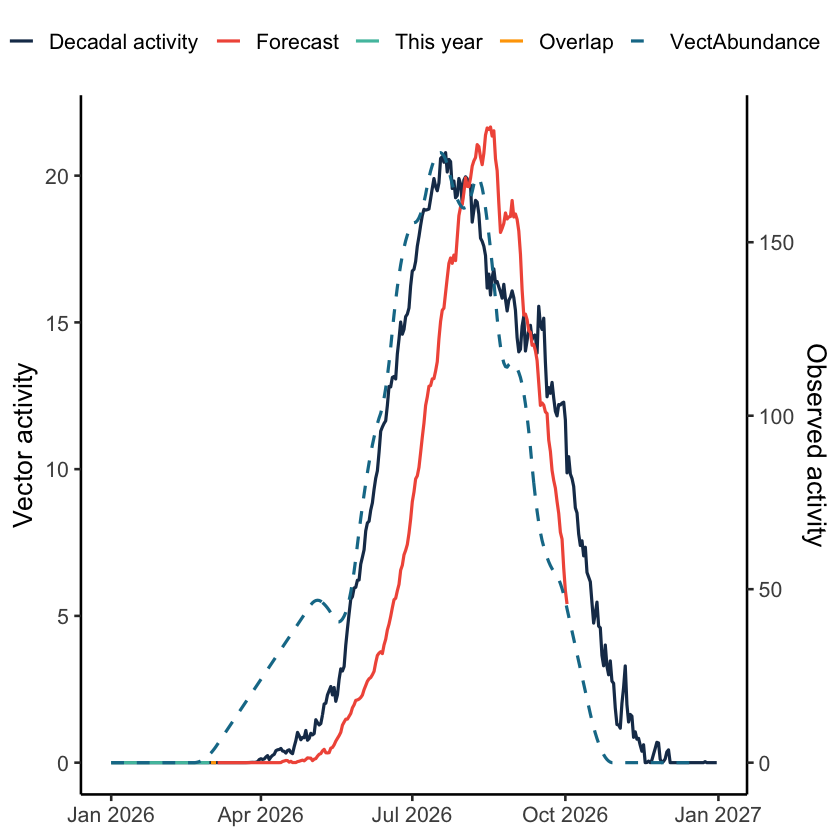

In [59]:
scale_factor <- max(df_surv$value, na.rm=TRUE) / max(df_dec$value, na.rm=TRUE)

ggplot() +
  geom_line(data = df_dec, aes(date, value, colour = "Decadal"), linewidth = 0.9) +
  geom_line(data = df_f, aes(date, value, colour = series), linewidth = 0.9) +
  geom_line(data = df_surv, aes(date, value / scale_factor, colour = "VectAbundance"), na.rm = TRUE, linetype = "dashed", linewidth = 0.9) +
  scale_y_continuous(
    name = "Vector activity",
    sec.axis = sec_axis(~ . * scale_factor, name = "Observed activity")
  ) +
  scale_colour_manual(
    values = c(
      "Decadal"    = "#1b3958",
      "ERA5 only"  = "#50c0ad",
      "Overlap"    = "orange",
      "ECMWF only" = "#f15a48",
      "VectAbundance" = "#167997"

    ),
    labels = c(
      "Decadal"    = "Decadal activity",
      "ERA5 only"  = "This year",
      "Overlap"    = "Overlap",
      "ECMWF only" = "Forecast",
      "VectAbundance" = "VectAbundance"
    )
  ) +
  labs(
    x = NULL,
    y = "Vector activity",
    colour = NULL
  ) +
  theme_classic(base_size = 16) +
  theme(
    legend.position = "top"
  )

This produces a combined visualisation of the long-term reference signal, the current seasonal outlook, and (optionally) observational data, enabling direct comparison between climatology, forecast, and field measurements.